# Data Generation

## Load Ausgrid dataset

In [125]:
import os
import pandas as pd

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')

csv_filepath_1 = os.path.join(data_dir, 'Solar home 2010-2011.csv')
csv_filepath_2 = os.path.join(data_dir, 'Solar home 2011-2012.csv')
csv_filepath_3 = os.path.join(data_dir, 'Solar home 2012-2013.csv')

# Load the three yearly files
df_2010 = pd.read_csv(csv_filepath_1, skiprows=1)
df_2011 = pd.read_csv(csv_filepath_2, skiprows=1)
df_2012 = pd.read_csv(csv_filepath_3, skiprows=1)

### Inspect dataset

In [126]:
# Inspect each file
for name, df in [('2010-2011', df_2010), ('2011-2012', df_2011), ('2012-2013', df_2012)]:
    print(f"Name: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns:", df.columns.tolist())
    print(f"Missing values: {df.isna().sum().sum()}\n")

Name: 2010-2011
Shape: (269735, 53)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00']
Missing values: 0

Name: 2011-2012
Shape: (270304, 54)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00'

#### Inspect `Row Quality` column

The `2011-2012` and `2012-2013` datasets have an additional `Row Quality` column. The Ausgrid documentation states `Row Quality` distinguishes actual (blank) readings from non-actual (NA) readings. Let's read the unique values in `Row Quality` and how often each occurs, including missing values.

In [127]:
for name, df in [('2011-2012', df_2011), ('2012-2013', df_2012)]:
    print(f"\n{name}:")
    print(df['Row Quality'].value_counts(dropna=False))


2011-2012:
Row Quality
NaN    270304
Name: count, dtype: int64

2012-2013:
Row Quality
NaN    268557
Name: count, dtype: int64


It seems like this column contains only `NaN`. As this column contains no real information, we will drop it.

In [128]:
df_2011 = df_2011.drop(columns=['Row Quality'], errors='ignore')
df_2012 = df_2012.drop(columns=['Row Quality'], errors='ignore')

### Merge all three years

In [129]:
ausgrid_df = pd.concat([df_2010, df_2011, df_2012], ignore_index=True)

#### Inspect merged dataset

In [130]:
# Inspect table
print(f"Name: Combined 2010-2013")
print(f"Shape: {ausgrid_df.shape}")
print(f"Columns: {ausgrid_df.columns.tolist()}")
print(f"Missing values: {ausgrid_df.isna().sum().sum()}\n")

Name: Combined 2010-2013
Shape: (808596, 53)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00']
Missing values: 0



### Reformat data
The dataset includes a column for every half-hour. First, let's convert the wide format to the tidier long format. 

In [131]:
# Half-hour columns
time_cols = ausgrid_df.columns[5:]

ausgrid_df_long = ausgrid_df.melt(
    id_vars=df.columns[:5],
    value_vars=time_cols,
    var_name='time',
    value_name='kWh')

# Inspect table
print(f"Name: Combined 2010-2013: Long")
print(f"Shape: {ausgrid_df_long.shape}")
print(f"Columns: {ausgrid_df_long.columns.tolist()}")
print(f"Missing values: {ausgrid_df_long.isna().sum().sum()}\n")

# Display long format dataset
ausgrid_df_long.head()

Name: Combined 2010-2013: Long
Shape: (38812608, 7)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', 'time', 'kWh']
Missing values: 0



,Customer,Generator Capacity,Postcode,Consumption Category,date,time,kWh
0,1,3.78,2076,GC,1-Jul-10,0:30,0.303
1,1,3.78,2076,CL,1-Jul-10,0:30,1.250
2,1,3.78,2076,GG,1-Jul-10,0:30,0.000
3,1,3.78,2076,GC,2-Jul-10,0:30,0.116
4,1,3.78,2076,CL,2-Jul-10,0:30,1.238


### Convert datetime columns
The dataset uses two string columns for `date` and `time`. Let's convert this to a single standard datetime column with the proper variable type. The `date` column is inconsistently formatted, so we use `format='mixed'` to handle multiple date styles such as `1-Jul-10` and `1/07/2011`. 

In [132]:
# Create timestamp
datetime = pd.to_datetime(
    ausgrid_df_long['date'].astype(str) + " " + ausgrid_df_long['time'],
    format='mixed',
    dayfirst=True,
    errors='coerce')

In [133]:
# Check number of NaT's
print(f"Invalid datetimes: {datetime.isna().sum()}/{len(datetime)}") 

Invalid datetimes: 0/38812608


In [134]:
# Add new datetime column
ausgrid_df_dtconverted = ausgrid_df_long.copy()
ausgrid_df_dtconverted['datetime'] = datetime

# Drop old date and time columns
ausgrid_df_dtconverted.drop(columns=['date', 'time'], inplace=True)

# Drop rows where datetime is NaT
ausgrid_df_dtconverted = ausgrid_df_dtconverted.dropna(subset=['datetime'])

# Inspect table
print(f"Name: Combined 2010-2013: Converted Datetime Column")
print(f"Shape: {ausgrid_df_dtconverted.shape}")
print(f"Columns: {ausgrid_df_dtconverted.columns.tolist()}")
print(f"Missing values: {ausgrid_df_dtconverted.isna().sum().sum()}\n")

# Display converted table
ausgrid_df_dtconverted.head()

Name: Combined 2010-2013: Converted Datetime Column
Shape: (38812608, 6)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'kWh', 'datetime']
Missing values: 0



,Customer,Generator Capacity,Postcode,Consumption Category,kWh,datetime
0,1,3.78,2076,GC,0.303,2010-07-01 00:30:00
1,1,3.78,2076,CL,1.250,2010-07-01 00:30:00
2,1,3.78,2076,GG,0.000,2010-07-01 00:30:00
3,1,3.78,2076,GC,0.116,2010-07-02 00:30:00
4,1,3.78,2076,CL,1.238,2010-07-02 00:30:00


### Create load columns
#### Investigate Consumption Categories

In [135]:
print(
    ausgrid_df_dtconverted['Consumption Category']
    .value_counts())

Consumption Category
GC    15778512
GG    15778512
CL     7255584
Name: count, dtype: int64


`CL` only has 7,228,656 rows while `GC` and `GG` each have 725,6016. Recall, we already removed customers who completely lacked `Cl` measurements from the dataset. Before proceeding, let's investigate the remaining missing `CL` data.

In [136]:
cl_counts = (
    cl_data
    .groupby('Customer')
    .size())
print(cl_counts.describe())

count      138.000000
mean     52381.565217
std        783.607594
min      48720.000000
25%      52608.000000
50%      52608.000000
75%      52608.000000
max      52608.000000
dtype: float64


Across the 138 customers, the number of CL observations varies, with a mean of 52,382 a minimum of 48,720, and a maximum of 52,608, which represents three complete years of 30-minute data. This shows that most customers have complete `CL` data for all three years, but come customers have substantial gaps. We will have two options.

1. Remove timesteps with missing `CL`.
2. Esitmate the missing `CL` values.

First, we will make the pivot table, as this will convert out implicit missing values to explicit missing values.

#### Create pivot table

In [137]:
# Create Pivot Table
ausgrid_loadconverted = ausgrid_df_dtconverted.pivot_table(
    index=['Customer', 'Generator Capacity', 'Postcode', 'datetime'],
    columns='Consumption Category',
    values='kWh',
    aggfunc='sum'
).reset_index()

# Inspect Pivot Table
print(f"Name: Ausgrid Pivot Table")
print(f"Shape: {ausgrid_loadconverted.shape}")
print(f"Columns: {ausgrid_loadconverted.columns.tolist()}")
print(f"Missing values: {ausgrid_loadconverted.isna().sum().sum()}")

ausgrid_loadconverted.head()

Name: Ausgrid Pivot Table
Shape: (15778512, 7)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'CL', 'GC', 'GG']
Missing values: 8522928


Consumption Category,Customer,Generator Capacity,Postcode,datetime,CL,GC,GG
0,1,3.78,2076,2010-07-01 00:00:00,1.075,0.125,0.0
1,1,3.78,2076,2010-07-01 00:30:00,1.250,0.303,0.0
2,1,3.78,2076,2010-07-01 01:00:00,1.244,0.471,0.0
3,1,3.78,2076,2010-07-01 01:30:00,1.256,0.083,0.0
4,1,3.78,2076,2010-07-01 02:00:00,0.744,0.121,0.0


#### Inspect missing values

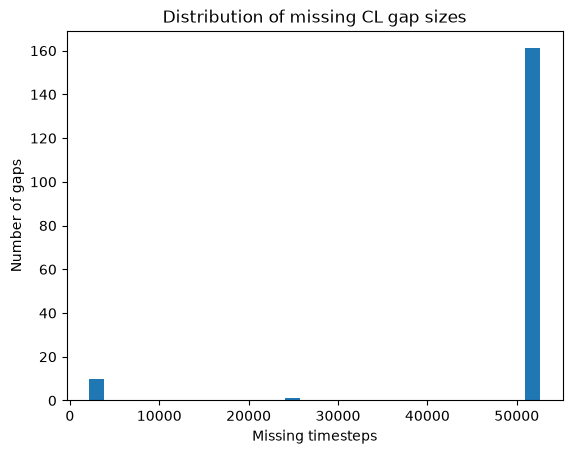

In [138]:
# Find consecutive blocks of missing CL values
df = ausgrid_loadconverted.sort_values(['Customer', 'datetime']).copy()
df['CL_missing'] = df['CL'].isna()

blocks = []

for customer, g in df.groupby('Customer'):
    g = g.reset_index(drop=True)
    group = g['CL_missing'].ne(g['CL_missing'].shift()).cumsum()

    for _, block in g[g['CL_missing']].groupby(group[g['CL_missing']]):
        blocks.append({
            'Customer': customer,
            'start': block['datetime'].iloc[0],
            'end': block['datetime'].iloc[-1],
            'missing_steps': len(block),
            'gap_hours': len(block) * 0.5
        })
missing_blocks = pd.DataFrame(blocks)

import matplotlib.pyplot as plt
plt.hist(missing_blocks['missing_steps'], bins=30)
plt.xlabel('Missing timesteps')
plt.ylabel('Number of gaps')
plt.title('Distribution of missing CL gap sizes')
plt.show()

This reveals that most missing `CL` values are in large, contiguous blocks, rather than individual missing timesteps. The gaps shown are roughly 2,200-3,100 half-hour timesteps, corresponding to about 46-65 days of missing data. Interpolation across individual missing points is not appropriate.

### Create load categories

In [139]:
ausgrid_loadconverted['Pload'] = ausgrid_loadconverted['CL'] + ausgrid_loadconverted['GC']
ausgrid_loadconverted['PPV'] = ausgrid_loadconverted['GG']
ausgrid_loadconverted['Pnet'] = ausgrid_loadconverted['Pload'] + ausgrid_loadconverted['PPV']
ausgrid_loadconverted.drop(columns=['CL','GC','GG'], inplace=True)

In [140]:
# Inspect table
print(f"Name: Ausgrid load data")
print(f"Shape: {ausgrid_loadconverted.shape}")
print(f"Columns: {ausgrid_loadconverted.columns.tolist()}")
print(f"Missing values: {ausgrid_loadconverted.isna().sum().sum()}")

ausgrid_loadconverted.head()

Name: Ausgrid load data
Shape: (15778512, 7)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'Pload', 'PPV', 'Pnet']
Missing values: 17045856


Consumption Category,Customer,Generator Capacity,Postcode,datetime,Pload,PPV,Pnet
0,1,3.78,2076,2010-07-01 00:00:00,1.200,0.0,1.200
1,1,3.78,2076,2010-07-01 00:30:00,1.553,0.0,1.553
2,1,3.78,2076,2010-07-01 01:00:00,1.715,0.0,1.715
3,1,3.78,2076,2010-07-01 01:30:00,1.339,0.0,1.339
4,1,3.78,2076,2010-07-01 02:00:00,0.865,0.0,0.865


### Final Datasets
We will create two datasets. One will contain all records, and only `PPV`. The other will contain `Pload`, `PPV`, and `Pnet`, but only for datetimes where `CL` was measured.

In [141]:
# Dataset 1: all records, only PPV
ausgrid_ppv = ausgrid_loadconverted[['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV']].copy()

# Inspect table
print(f"Name: Ausgrid PV Generation Data")
print(f"Shape: {ausgrid_ppv.shape}")
print(f"Columns: {ausgrid_ppv.columns.tolist()}")
print(f"Missing values: {ausgrid_ppv.isna().sum().sum()}")
ausgrid_ppv.head()

# Dataset 2: only records where CL was measured
ausgrid_complete = ausgrid_loadconverted.dropna(subset=['Pload'])[['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'Pload', 'PPV', 'Pnet']].copy()

# Inspect table
print(f"Name: Ausgrid PV Generation and Load Data")
print(f"Shape: {ausgrid_complete.shape}")
print(f"Columns: {ausgrid_complete.columns.tolist()}")
print(f"Missing values: {ausgrid_complete.isna().sum().sum()}")
ausgrid_ppv.head()

Name: Ausgrid PV Generation Data
Shape: (15778512, 5)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV']
Missing values: 0
Name: Ausgrid PV Generation and Load Data
Shape: (7255584, 7)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'Pload', 'PPV', 'Pnet']
Missing values: 0


Consumption Category,Customer,Generator Capacity,Postcode,datetime,PPV
0,1,3.78,2076,2010-07-01 00:00:00,0.0
1,1,3.78,2076,2010-07-01 00:30:00,0.0
2,1,3.78,2076,2010-07-01 01:00:00,0.0
3,1,3.78,2076,2010-07-01 01:30:00,0.0
4,1,3.78,2076,2010-07-01 02:00:00,0.0


#### Clean up old datasets

In [142]:
if 'df_2010' in globals(): del df_2010
if 'df_2011' in globals(): del df_2011
if 'df_2012' in globals(): del df_2012
if 'ausgrid_df' in globals(): del ausgrid_df
if 'ausgrid_df_long' in globals(): del ausgrid_df_long
if 'ausgrid_df_dtconverted' in globals(): del ausgrid_df_dtconverted
if 'ausgrid_loadconverted' in globals(): del ausgrid_loadconverted

## Load Weather Data
`archive-api.open-meteo.com` is the Open-Meteo Historical Weather API. It provides historical weather data for specified latidue/longitude and date range. The archive goes back to 1940 and is primarily based on reanalysis datasets such as ERA5/ERA5-Land. 

In [143]:
import requests
import pandas as pd

# Approximate location for Australian postcode 2076
lat = -33.72
lon = 151.12

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    'latitude': lat,
    'longitude': lon,
    'start_date': '2010-07-01',
    'end_date': '2013-06-30',
    'hourly': 'temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration',
    'models': 'era5',
    'timezone': 'Australia/Sydney',
    'temperature_unit': 'celsius',
    'precipitation_unit': 'mm'}

response = requests.get(url, params=params)
response.raise_for_status()

weather = pd.DataFrame(response.json()['hourly'])

### Inspect weather data

In [144]:
# Inspect data
print(f"Name: Weather 2010-2013")
print(f"Shape: {weather.shape}")
print(f"Columns: {weather.columns.tolist()}")
print(f"Missing values: {weather.isna().sum().sum()}\n")
weather.head()

Name: Weather 2010-2013
Shape: (26304, 8)
Columns: ['time', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration']
Missing values: 0



,time,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration
0,2010-07-01T00:00,3.6,8.3,0.0,1,0.0,0.0,0.0
1,2010-07-01T01:00,3.3,8.4,0.0,9,0.0,0.0,0.0
2,2010-07-01T02:00,2.2,8.5,0.0,22,0.0,0.0,0.0
3,2010-07-01T03:00,2.0,8.2,0.0,9,0.0,0.0,0.0
4,2010-07-01T04:00,1.8,8.2,0.0,13,0.0,0.0,0.0


### Create standard datetime column

In [145]:
# Create standard datetime column
weather_dtconverted = weather.copy()
weather_dtconverted['datetime'] = pd.to_datetime(weather_dtconverted['time'])
weather_dtconverted.drop(columns=['time'], inplace=True)

weather_dtconverted.head()

,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration,datetime
0,3.6,8.3,0.0,1,0.0,0.0,0.0,2010-07-01 00:00:00
1,3.3,8.4,0.0,9,0.0,0.0,0.0,2010-07-01 01:00:00
2,2.2,8.5,0.0,22,0.0,0.0,0.0,2010-07-01 02:00:00
3,2.0,8.2,0.0,9,0.0,0.0,0.0,2010-07-01 03:00:00
4,1.8,8.2,0.0,13,0.0,0.0,0.0,2010-07-01 04:00:00


#### Interpolate datetimes to match Ausgrid data time resolution

In [146]:
# Interpolate hourly data to 30-minute resolution
weather_interpolated = (
    weather_dtconverted.set_index('datetime')
    .resample('30min')
    .interpolate()
    .reset_index())

weather_interpolated.head()

,datetime,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration
0,2010-07-01 00:00:00,3.60,8.30,0.0,1.0,0.0,0.0,0.0
1,2010-07-01 00:30:00,3.45,8.35,0.0,5.0,0.0,0.0,0.0
2,2010-07-01 01:00:00,3.30,8.40,0.0,9.0,0.0,0.0,0.0
3,2010-07-01 01:30:00,2.75,8.45,0.0,15.5,0.0,0.0,0.0
4,2010-07-01 02:00:00,2.20,8.50,0.0,22.0,0.0,0.0,0.0


### Final dataset

In [147]:
weather_final = weather_interpolated.copy()
if 'weather' in globals(): del weather
if 'weather_dtconverted' in globals(): del weather_dtconverted
if 'weather_interpolated' in globals(): del weather_interpolated

### Calculate Sun Position
$\theta_\text{sun} = \sin \phi \sin \delta + \cos \phi \cos \delta \cos H$
- $\delta$ = solar declination, determined by the date.
- $H$ = solar hour angle, determined by time of day.

$\delta = 23.45 \degree \sin (\frac{360 \degree}{365}(284 + n))$
- $n$ = day of year (1-365)

In [156]:
import numpy as np

lat = 33.9 # system latitude (degrees)
lon = 151.2 # system longitude (degrees)

# Convert string to datetime type
ausgrid_ppv["datetime"] = pd.to_datetime(ausgrid_ppv["datetime"])

# Decompose datetime
sun = pd.DataFrame({"datetime": ausgrid_ppv["datetime"]})
sun["day_of_year"] = sun["datetime"].dt.dayofyear
sun["hour"] = sun["datetime"].dt.hour + sun["datetime"].dt.minute / 60

# Solar declination
sun["declination_angle"] = np.radians(23.45 * np.sin(np.radians((360 / 365) * (284 + sun["day_of_year"]))))

# Solar hour angle (simplified: 15° per hour from solar noon)
hour_angle = np.radians(15 * (sun['hour'] - 12))

# Solar zenith angle
lat_rad = np.radians(lat)
sun["sun_position"] = np.degrees(np.arccos(
    np.sin(lat_rad) * np.sin(sun["declination_angle"]) +
    np.cos(lat_rad) * np.cos(sun["declination_angle"]) * np.cos(hour_angle)))

# Make sure sun does not have duplicate datetime values
sun = sun[["datetime", "sun_position"]].drop_duplicates("datetime")

sun.head()

,datetime,sun_position
0,2010-07-01 00:00:00,122.979516
1,2010-07-01 00:30:00,122.534587
2,2010-07-01 01:00:00,121.220214
3,2010-07-01 01:30:00,119.093277
4,2010-07-01 02:00:00,116.236036


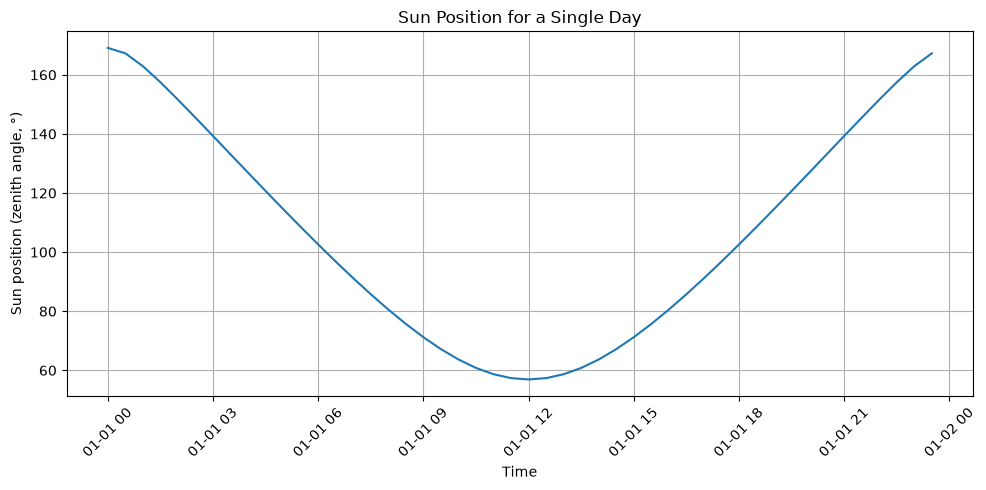

In [157]:
# Plot sun position for a single day
single_day = sun[sun["datetime"].dt.date == pd.Timestamp("2012-01-01").date()]

plt.figure(figsize=(10, 5))
plt.plot(single_day["datetime"], single_day["sun_position"])
plt.xlabel("Time")
plt.ylabel("Sun position (zenith angle, °)")
plt.title("Sun Position for a Single Day")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Combine Datasets

In [158]:
ausgrid_ppv_merged = ausgrid_ppv.merge(weather_final, on='datetime', how='left').merge(sun[["datetime", "sun_position"]], on="datetime", how="left")

# Inspect data
print(f"Name: Merged load and weather dataset")
print(f"Shape: {ausgrid_ppv_merged.shape}")
print(f"Columns: {ausgrid_ppv_merged.columns.tolist()}")
print(f"Missing values: {ausgrid_ppv_merged.isna().sum().sum()}\n")

Name: Merged load and weather dataset
Shape: (15778512, 13)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration', 'sun_position']
Missing values: 2100



In [159]:
ausgrid_complete_merged = ausgrid_complete.merge(weather_final, on='datetime', how='left')

# Inspect data
print(f"Name: Merged load and weather dataset")
print(f"Shape: {ausgrid_complete_merged.shape}")
print(f"Columns: {ausgrid_complete_merged.columns.tolist()}")
print(f"Missing values: {ausgrid_complete_merged.isna().sum().sum()}\n")

Name: Merged load and weather dataset
Shape: (7255584, 14)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'Pload', 'PPV', 'Pnet', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration']
Missing values: 966



Merging two datasets can introduce missing values even when both input Dataframes have none. If an `ausgrid_final['datetime']` value does not have a corresponding `datetime` in `weather_final`, Pandas fills all the weather columns for that row with `NaN`. Let's check how many and which timestamps don't match.

### Remove missing values

In [160]:
ausgrid_ppv_merged = ausgrid_ppv_merged.dropna().copy()
# Inspect data
print(f"Name: Merged load and weather dataset")
print(f"Shape: {ausgrid_ppv_merged.shape}")
print(f"Columns: {ausgrid_ppv_merged.columns.tolist()}")
print(f"Missing values: {ausgrid_ppv_merged.isna().sum().sum()}\n")
ausgrid_ppv_merged.head()

Name: Merged load and weather dataset
Shape: (15778212, 13)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration', 'sun_position']
Missing values: 0



,Customer,Generator Capacity,Postcode,datetime,PPV,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration,sun_position
0,1,3.78,2076,2010-07-01 00:00:00,0.0,3.60,8.30,0.0,1.0,0.0,0.0,0.0,122.979516
1,1,3.78,2076,2010-07-01 00:30:00,0.0,3.45,8.35,0.0,5.0,0.0,0.0,0.0,122.534587
2,1,3.78,2076,2010-07-01 01:00:00,0.0,3.30,8.40,0.0,9.0,0.0,0.0,0.0,121.220214
3,1,3.78,2076,2010-07-01 01:30:00,0.0,2.75,8.45,0.0,15.5,0.0,0.0,0.0,119.093277
4,1,3.78,2076,2010-07-01 02:00:00,0.0,2.20,8.50,0.0,22.0,0.0,0.0,0.0,116.236036


In [161]:
ausgrid_complete_merged = ausgrid_complete_merged.dropna().copy()
# Inspect data
print(f"Name: Merged load and weather dataset")
print(f"Shape: {ausgrid_complete_merged.shape}")
print(f"Columns: {ausgrid_complete_merged.columns.tolist()}")
print(f"Missing values: {ausgrid_complete_merged.isna().sum().sum()}\n")
ausgrid_complete_merged.head()

Name: Merged load and weather dataset
Shape: (7255446, 14)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'Pload', 'PPV', 'Pnet', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration']
Missing values: 0



,Customer,Generator Capacity,Postcode,datetime,Pload,PPV,Pnet,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration
0,1,3.78,2076,2010-07-01 00:00:00,1.200,0.0,1.200,3.60,8.30,0.0,1.0,0.0,0.0,0.0
1,1,3.78,2076,2010-07-01 00:30:00,1.553,0.0,1.553,3.45,8.35,0.0,5.0,0.0,0.0,0.0
2,1,3.78,2076,2010-07-01 01:00:00,1.715,0.0,1.715,3.30,8.40,0.0,9.0,0.0,0.0,0.0
3,1,3.78,2076,2010-07-01 01:30:00,1.339,0.0,1.339,2.75,8.45,0.0,15.5,0.0,0.0,0.0
4,1,3.78,2076,2010-07-01 02:00:00,0.865,0.0,0.865,2.20,8.50,0.0,22.0,0.0,0.0,0.0


In [153]:
### Save data
complete_df_filepath = os.path.join(data_dir, 'ausgrid_complete.csv')
ppv_df_filepath = os.path.join(data_dir, 'ausgrid_ppv.csv')

ausgrid_complete_merged.to_csv(complete_df_filepath, index=False)
ausgrid_ppv_merged.to_csv(ppv_df_filepath, index=False)